# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

In [37]:
import pandas as pd

df = pd.read_csv('developer_survey.csv')

df.head()

,respondent_id,programming_language,experience_years,sentiment,developer_role,location,comment
0,1,Python,3,positive,data_scientist,California,Python's syntax is incredibly clean and readab...
1,2,JavaScript,5,mixed,frontend_developer,New_York,JavaScript is powerful but can be frustrating ...
2,3,Java,7,positive,backend_developer,Texas,Java's strong typing and enterprise features m...
3,4,C++,10,mixed,systems_programmer,Washington,C++ gives you incredible control but the learn...
4,5,Python,2,positive,student,Louisiana,Love how quickly I can prototype ideas in Pyth...


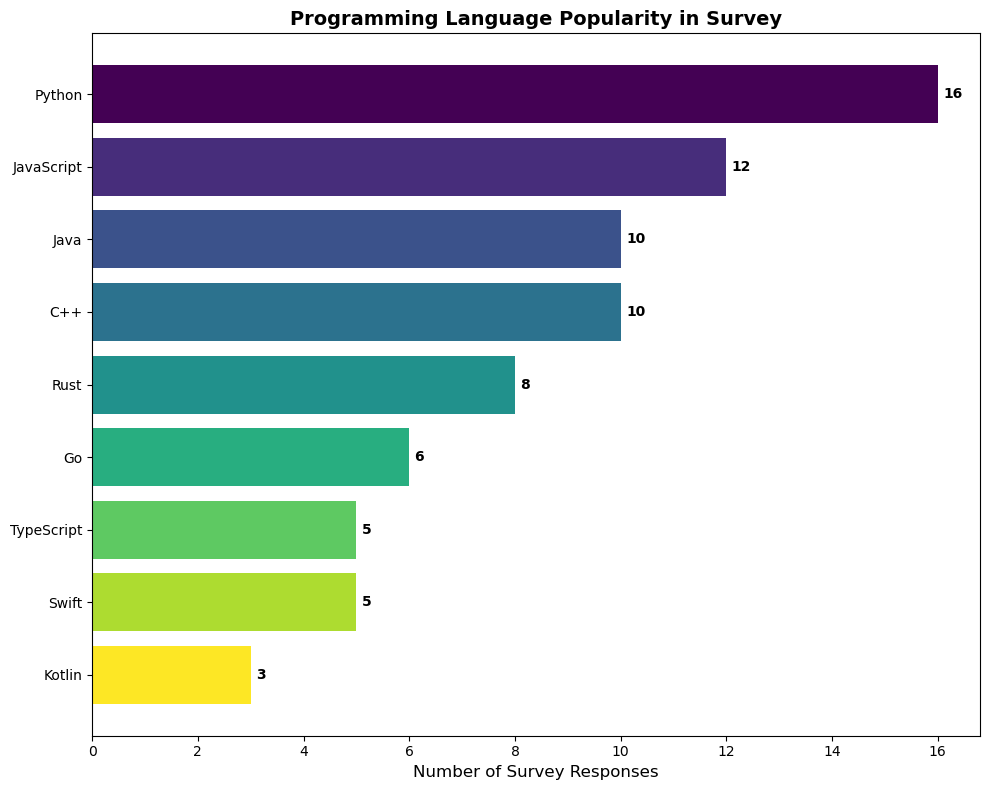

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import string
import numpy as np

df = pd.read_csv('developer_survey.csv')


def create_language_popularity_chart():

    lang_counts = df['programming_language'].value_counts()
    
    plt.figure(figsize=(10, 8))
    
    # Create horizontal bar chart
    bars = plt.barh(range(len(lang_counts)), lang_counts.values, 
                   color=plt.cm.viridis(np.linspace(0, 1, len(lang_counts))))
    
    # Customize the chart
    plt.yticks(range(len(lang_counts)), lang_counts.index)
    plt.xlabel('Number of Survey Responses', fontsize=12)
    plt.title('Programming Language Popularity in Survey', fontsize=14, fontweight='bold')
    
    # Add value labels on bars
    for i, (bar, count) in enumerate(zip(bars, lang_counts.values)):
        plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                str(count), ha='left', va='center', fontweight='bold')
    
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

create_language_popularity_chart()



## Interpretation:
This reflects Python's growing dominance in data science and general programming.

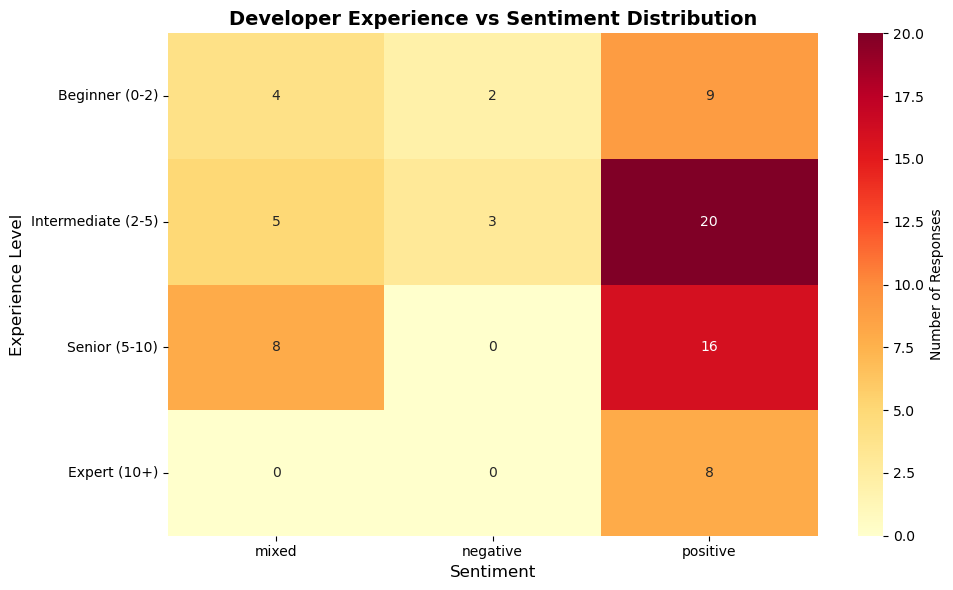

In [39]:


def create_experience_sentiment_heatmap():

    # Create experience categories
    df['experience_category'] = pd.cut(df['experience_years'], 
                                      bins=[0, 2, 5, 10, 20], 
                                      labels=['Beginner (0-2)', 'Intermediate (2-5)', 
                                             'Senior (5-10)', 'Expert (10+)'])
    
    # Create cross-tabulation
    crosstab = pd.crosstab(df['experience_category'], df['sentiment'])
    
    plt.figure(figsize=(10, 6))
    
    # Create heatmap
    sns.heatmap(crosstab, 
                annot=True,
                fmt='d',
                cmap='YlOrRd',
                cbar_kws={'label': 'Number of Responses'})
    
    plt.title('Developer Experience vs Sentiment Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Sentiment', fontsize=12)
    
    plt.ylabel('Experience Level', fontsize=12)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

create_experience_sentiment_heatmap()



## Interpretation:

The heatmap reveals how sentiment varies across experience levels. More experienced developers may have different perspectives on language trade-offs.

C:\Users\davin\AppData\Local\Temp\ipykernel_33152\3683113549.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot([df[df['sentiment'] == sent]['comment_length']


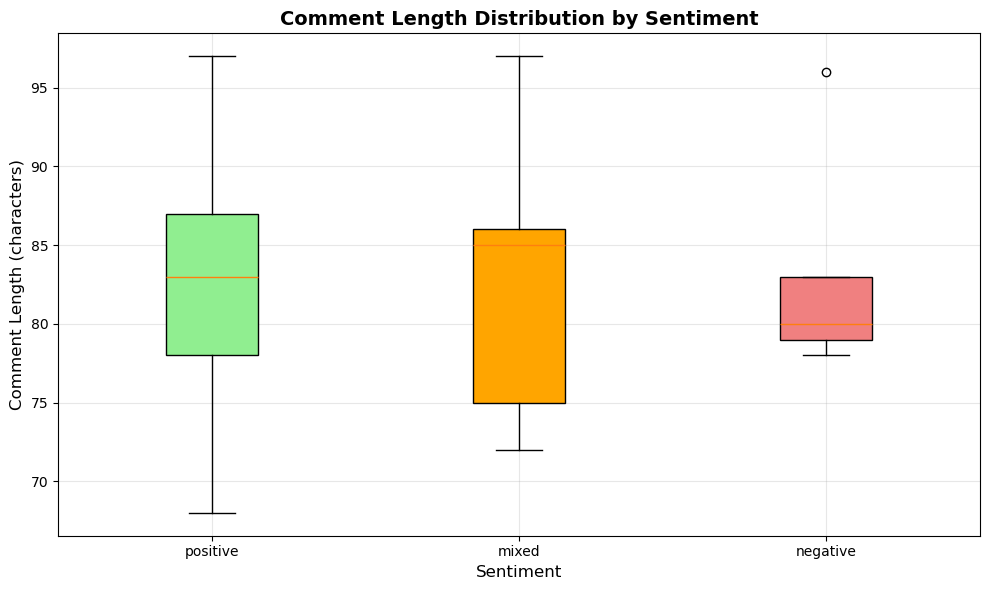

In [40]:


def create_comment_length_analysis():
    
    # Calculate comment lengths
    df['comment_length'] = df['comment'].str.len()
    
    plt.figure(figsize=(10, 6))
    
    # Create box plot
    sentiment_order = ['positive', 'mixed', 'negative']
    box_plot = plt.boxplot([df[df['sentiment'] == sent]['comment_length'] 
                           for sent in sentiment_order],
                          labels=sentiment_order,
                          patch_artist=True)
    
    # Color the boxes
    colors = ['lightgreen', 'orange', 'lightcoral']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
    
    plt.xlabel('Sentiment', fontsize=12)
    plt.ylabel('Comment Length (characters)', fontsize=12)
    plt.title('Comment Length Distribution by Sentiment', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
create_comment_length_analysis()

## Interpretation:
Longer comments may indicate more detailed explanations of sentiment.